In [1]:
import pandas as pd

df = pd.read_csv("../data/spam.csv", encoding="latin-1")

df.head()


,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [2]:
df.shape


(5572, 5)

In [3]:
df.columns

Index(['v1', 'v2', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], dtype='str')

In [4]:
df = df[["v1", "v2"]]

df.head()

,v1,v2
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [5]:
df = df.rename(
    columns = {
        "v1": "label",
        "v2": "message"
    }
)

In [6]:
df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [7]:
df.shape

(5572, 2)

In [8]:
df.isnull().sum()

label      0
message    0
dtype: int64

In [9]:
df.duplicated().sum()


np.int64(403)

In [10]:
df = df.drop_duplicates()

In [11]:
df.shape

(5169, 2)

In [12]:
df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [13]:
df["label"].value_counts()

label
ham     4516
spam     653
Name: count, dtype: int64

In [14]:
import matplotlib.pyplot as plt

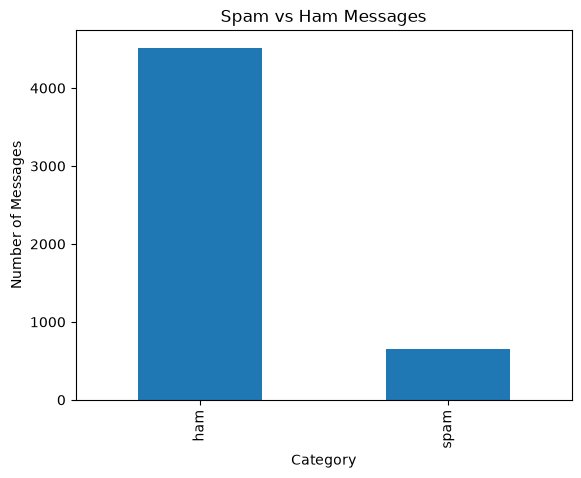

In [15]:
df["label"].value_counts().plot(
    kind = "bar")

plt.title("Spam vs Ham Messages")
plt.xlabel("Category")
plt.ylabel("Number of Messages")

plt.show()

In [16]:
df["label"].value_counts(normalize=True) * 100

label
ham     87.366996
spam    12.633004
Name: proportion, dtype: float64

In [17]:
df["message_length"] = df["message"].apply(len)

In [18]:
df.groupby("label")["message_length"].mean()

label
ham      70.459256
spam    137.891271
Name: message_length, dtype: float64

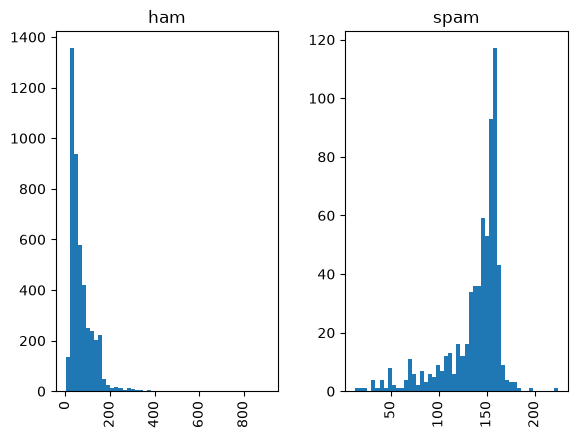

In [19]:
df.hist(
    column="message_length",
    by="label",
    bins=50
)

plt.show()
        

In [20]:
df['message'] = df['message'].str.lower()


In [21]:
import re

def remove_punctuation(text):
    text = re.sub(
        "[^a-zA-Z]",
        " ",
        text
    )

    return text

In [22]:
remove_punctuation(
    "Coungratulation!!! You won $10000"
)

'Coungratulation    You won       '

In [23]:
df['clean_message'] = df['message'].apply(remove_punctuation)

In [24]:
import nltk
from nltk.corpus import stopwords

stop_words = set(
    stopwords.words('english')
)


In [25]:
list(stop_words)[:10]

['further',
 'whom',
 'between',
 "hadn't",
 "it'll",
 'until',
 'while',
 'here',
 'on',
 'be']

In [26]:
def clean_text(text):
    text = text.lower()

    text = re.sub(
        "[^a-z]",
        " ",
        text

    )

    words = text.split()

    words = [
        word
        for word in words
        if word not in stop_words
    ]

    return " ".join(words)

In [27]:
df['clean_message'] = df['message'].apply(clean_text)

In [28]:
df[['message', 'clean_message']].head()

,message,clean_message
0,"go until jurong point, crazy.. available only ...",go jurong point crazy available bugis n great ...
1,ok lar... joking wif u oni...,ok lar joking wif u oni
2,free entry in 2 a wkly comp to win fa cup fina...,free entry wkly comp win fa cup final tkts st ...
3,u dun say so early hor... u c already then say...,u dun say early hor u c already say
4,"nah i don't think he goes to usf, he lives aro...",nah think goes usf lives around though


In [29]:
t = df['clean_message']
y = df['label']

In [30]:
t.head()

0    go jurong point crazy available bugis n great ...
1                              ok lar joking wif u oni
2    free entry wkly comp win fa cup final tkts st ...
3                  u dun say early hor u c already say
4               nah think goes usf lives around though
Name: clean_message, dtype: str

In [31]:
y = y.map({
    'ham': 0,
    'spam': 1
})


In [32]:
y.head()

0    0
1    0
2    1
3    0
4    0
Name: label, dtype: int64

In [33]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer()

X = tfidf.fit_transform(t)

In [34]:
X.shape

(5169, 7546)

In [35]:
print(X)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 41262 stored elements and shape (5169, 7546)>
  Coords	Values
  (0, 2619)	0.1563954393269625
  (0, 3376)	0.346855033220675
  (0, 4881)	0.27065405174183044
  (0, 1417)	0.2679523213844952
  (0, 448)	0.2630509880198985
  (0, 864)	0.2925683586857756
  (0, 2699)	0.19366194117263594
  (0, 7377)	0.24493485534812015
  (0, 3496)	0.2800978513097731
  (0, 862)	0.33097719877478987
  (0, 1146)	0.2925683586857756
  (0, 2660)	0.16225591351497312
  (0, 218)	0.346855033220675
  (0, 7170)	0.19405550788310333
  (1, 4488)	0.2767319100209511
  (1, 3529)	0.406925248497845
  (1, 3344)	0.5233434480300876
  (1, 7282)	0.4304438402468376
  (1, 4515)	0.5464988818914979
  (2, 2432)	0.1254282760380994
  (2, 2025)	0.3893997590633288
  (2, 7336)	0.21528841043343389
  (2, 1260)	0.21245741488560616
  (2, 7294)	0.162067830107421
  (2, 2161)	0.5261869975334182
  :	:
  (5164, 1910)	0.28646423851197034
  (5164, 4940)	0.334759885785594
  (5165, 2947)	0.3669629414

In [36]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size = 0.2,
    random_state = 42
)

In [37]:
X_train.shape


(4135, 7546)

In [38]:
X_test.shape

(1034, 7546)

In [39]:
y_train.shape

(4135,)

In [40]:
y_test.shape

(1034,)

In [41]:
from sklearn.naive_bayes import MultinomialNB

model = MultinomialNB()

model.fit(
    X_train,
    y_train
)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
Name,Type,Value
"class_count_ class_count_: ndarray of shape (n_classes,)Number of samples encountered for each class during fitting. Thisvalue is weighted by the sample weight when provided.","ndarray[float64](2,)","[3627., 508.]"
"class_log_prior_ class_log_prior_: ndarray of shape (n_classes,)Smoothed empirical log probability for each class.","ndarray[float64](2,)","[-0.13,-2.1 ]"
"classes_ classes_: ndarray of shape (n_classes,)Class labels known to the classifier","ndarray[int64](2,)","[0,1]"
"feature_count_ feature_count_: ndarray of shape (n_classes, n_features)Number of samples encountered for each (class, feature)during fitting. This value is weighted by the sample weight whenprovided.","ndarray[float64](2, 7546)","[[0.35,1.35,0.08,...,0. ,0. ,0. ], [0. ,0. ,0. ,...,0.32,0.32,0. ]]"
"feature_log_prob_ feature_log_prob_: ndarray of shape (n_classes, n_features)Empirical log probability of featuresgiven a class, ``P(x_i|y)``.","ndarray[float64](2, 7546)","[[-9.41,-8.85,-9.63,...,-9.71,-9.71,-9.71], [-9.14,-9.14,-9.14,...,-8.87,-8.86,-9.14]]"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,7546


In [42]:
y_pred = model.predict(
    X_test
)
print(y_pred)

[0 0 0 ... 1 0 0]


In [43]:
y_test[:10]

1617    0
2064    0
1272    0
3020    0
3642    0
1520    1
1159    0
3986    1
3217    0
539     0
Name: label, dtype: int64

In [44]:
y_pred[:20]

array([0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0])

In [45]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(
    y_test,
    y_pred
)

accuracy

0.9690522243713733

In [46]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.97      1.00      0.98       889
           1       1.00      0.78      0.88       145

    accuracy                           0.97      1034
   macro avg       0.98      0.89      0.93      1034
weighted avg       0.97      0.97      0.97      1034



In [47]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test,
    y_pred
)

cm

array([[889,   0],
       [ 32, 113]])

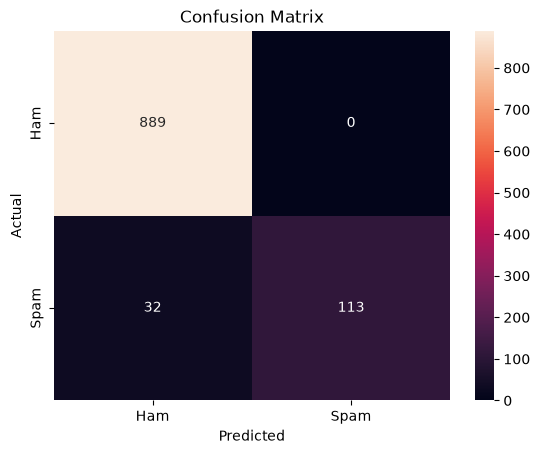

In [48]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["Ham", "Spam"],
    yticklabels=["Ham", "Spam"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()
    

In [49]:
accuracy_score(y_test, y_pred)

print(classification_report(y_test, y_pred))

confusion_matrix(y_test, y_pred)

              precision    recall  f1-score   support

           0       0.97      1.00      0.98       889
           1       1.00      0.78      0.88       145

    accuracy                           0.97      1034
   macro avg       0.98      0.89      0.93      1034
weighted avg       0.97      0.97      0.97      1034



array([[889,   0],
       [ 32, 113]])

In [50]:
message = [
    "Congratulations! You've won a $1,000 gift card. Click here to claim now!"
]

clean_message = [
    clean_text(message[0])
]

print(clean_message)

message_vector = tfidf.transform(clean_message)

prediction = model.predict(message_vector)


if prediction[0] == 1:
    print("Spam")

else:
    print("Ham")

probability = model.predict_proba(message_vector)

probability

['congratulations gift card click claim']
Spam


array([[0.29738164, 0.70261836]])

In [51]:
import pickle
import os

os.makedirs("models", exist_ok=True)

with open("models/spam_model.pkl", "wb") as file:
    pickle.dump(model, file)

with open("models/tfidf.pkl", "wb") as file:
    pickle.dump(tfidf, file)

os.listdir("models")

['tfidf.pkl', 'spam_model.pkl']